# ER

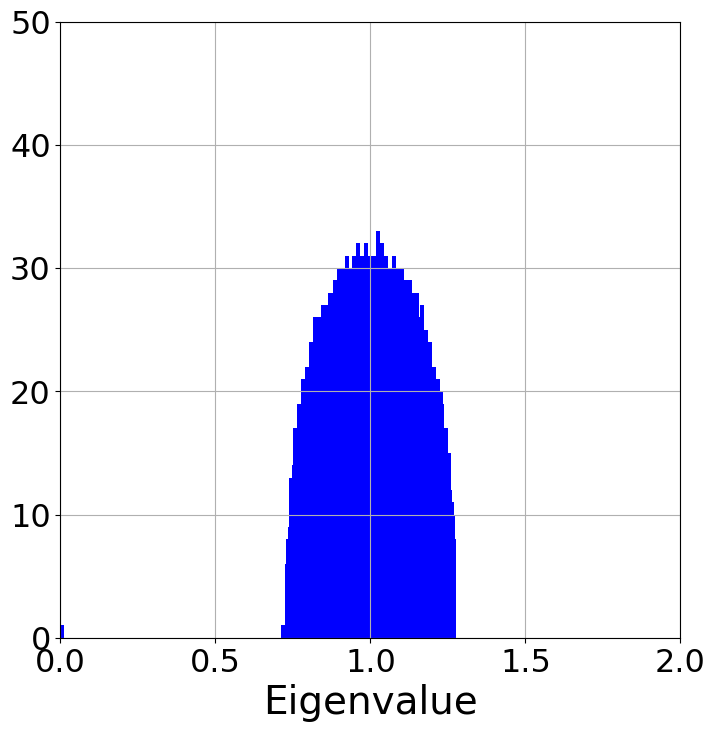

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 1000             # Number of nodes in the ER graph
p = 0.05              # Probability of edge creation p = 0.01, 0.05, 0.1
num_plots = 100      # Number of graph instances to generate


plt.figure(figsize=(8, 8))
for i in range(num_plots):
    G = nx.erdos_renyi_graph(n, p, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=1, color='b')  # Overlay 

plt.xlabel('Eigenvalue', fontsize = 28)
#plt.ylabel('Count', fontsize = 28)
plt.xticks([0, 0.5, 1, 1.5, 2], fontsize=23)
plt.yticks(fontsize=23)
plt.xlim(0, 2)
plt.ylim(0,50)
plt.grid(True)

file_name = f'Random_graph_plots/ER_p_{p}_n_{n}.png'
plt.savefig(file_name, dpi = 300)
plt.show()

# BA

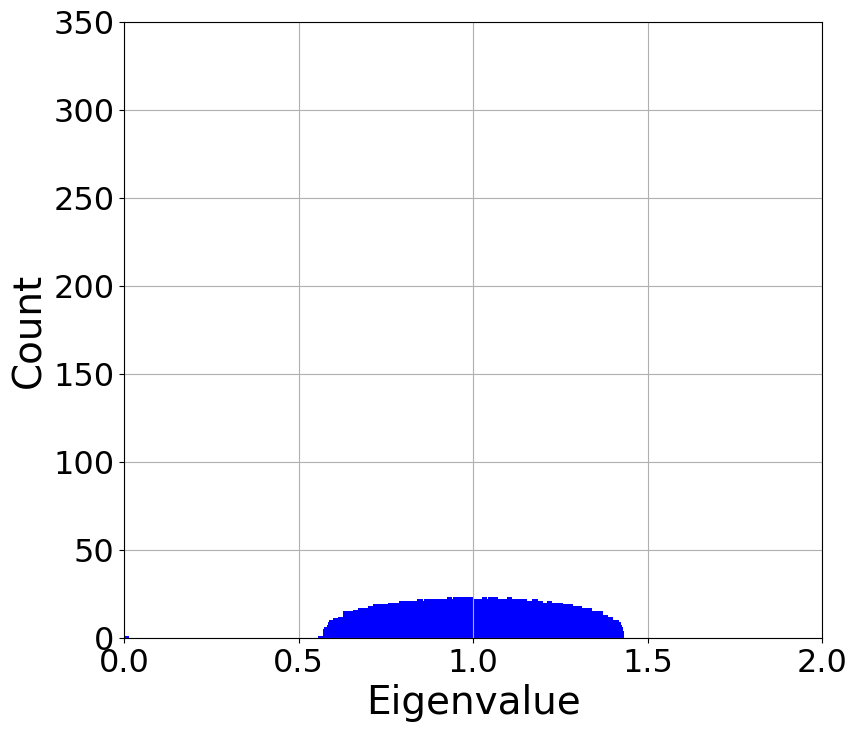

In [20]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 1000             # Number of nodes in the BA graph
m = 10                # Number of edges each new node connects to m= 1, 2, 3, 4, 10
num_plots = 100      # Number of graph instances to generate

plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = nx.barabasi_albert_graph(n, m, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=1, color='b')  

plt.xlabel('Eigenvalue', fontsize = 28)
plt.ylabel('Count', fontsize = 28)
plt.xticks([0, 0.5, 1, 1.5, 2], fontsize=23)
plt.yticks(fontsize=23)
plt.xlim(0, 2)
plt.ylim(0,350)
plt.grid(True)

file_name = f'Random_graph_plots/BA_m_{m}_n_{n}.png'
plt.savefig(file_name, dpi = 300)
plt.show()

# WS

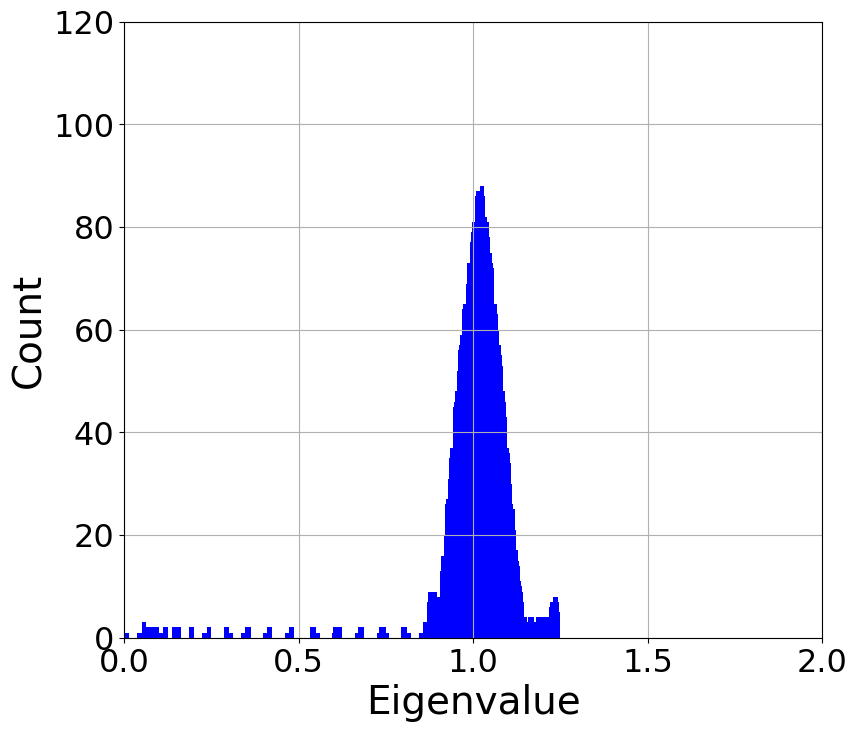

In [45]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 1000             # Number of nodes in the WS graph
k = 50                # Each node is initially connected to k nearest neighbors k = 2, 4, 10, 50
p = 0.05              # Probability of rewiring p = 0, 0.05, 0.1, 0.5
num_plots = 100      # Number of graph instances to generate


plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = nx.watts_strogatz_graph(n, k, p, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=1, color='b')  

    
plt.xlabel('Eigenvalue', fontsize = 28)
plt.ylabel('Count', fontsize = 28)
plt.xticks([0, 0.5, 1, 1.5, 2], fontsize=23)
plt.yticks(fontsize=23)
plt.xlim(0, 2)
plt.ylim(0,120)
plt.grid(True)

file_name = f'Random_graph_plots/WS_k_{k}_p_{p}_n_{n}.png'
plt.savefig(file_name, dpi = 300)
plt.show()

### WS with k=2, p=0 overlayed with the eigenvalues of a cycle

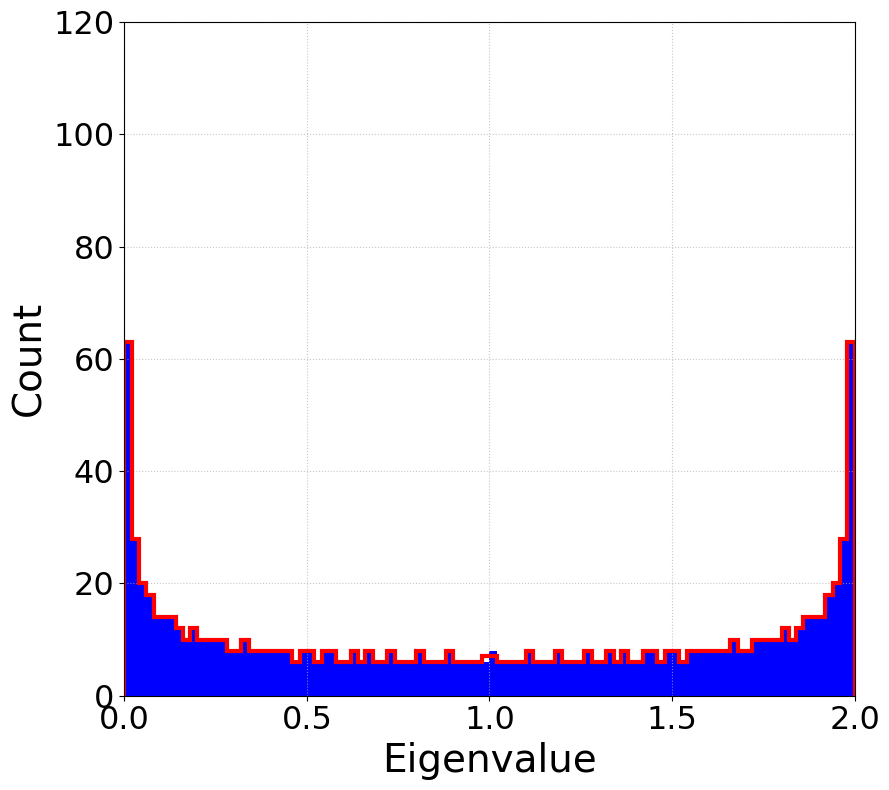

In [39]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 1000             
k_ws = 2                
p_ws = 0                
num_plots = 1     

plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = nx.watts_strogatz_graph(n, k_ws, p_ws, seed=i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=1, color='b')  


k_idx = np.arange(0, n)
y_analytical = 1 - np.cos(2 * np.pi * k_idx / n)
plt.hist(y_analytical, bins=100, density=False, histtype='step', 
         color='red', linewidth=3)

plt.xlabel('Eigenvalue', fontsize=28)
plt.ylabel('Count', fontsize=28)
plt.xticks([0, 0.5, 1, 1.5, 2], fontsize=23)
plt.yticks(fontsize=23)
plt.xlim(0, 2)
plt.ylim(0, 120)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig("WS_k_2_p_0_cos.png", dpi = 300)
plt.tight_layout()
plt.show()

# ER with leafs

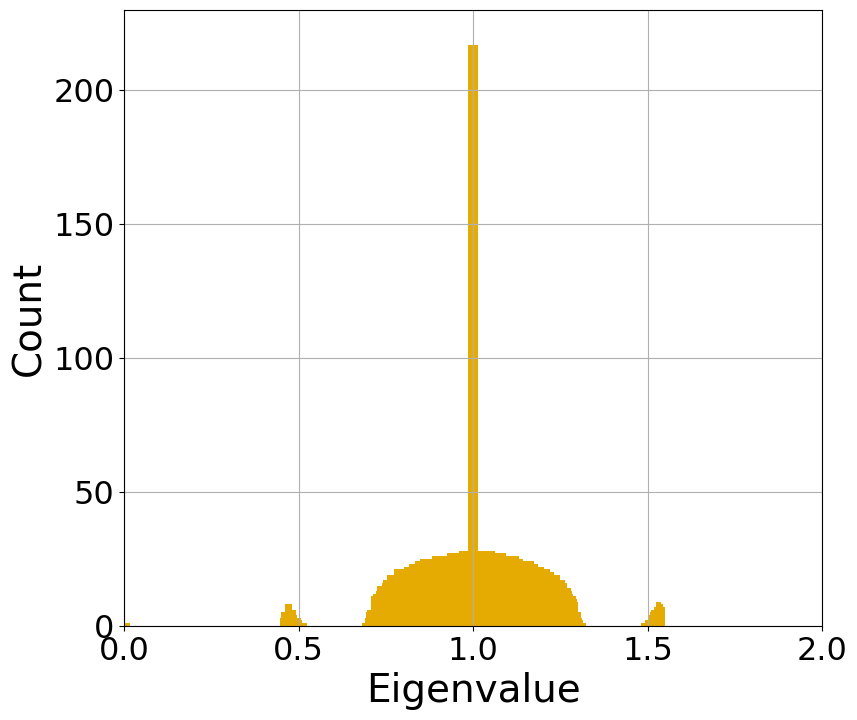

In [57]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 800             # Number of nodes in the ER graph
p = 0.05            # Probability of edge creation
num_leafs = 20      # Number of leaf nodes to add to the highest degree nodes
num_top_nodes = 10  # Number of highest degree nodes to add leaf nodes to
num_plots = 100     # Number of graph instances to generate

# Function to create the ER graph and add leaf nodes to the top "num_top_nodes" highest degree nodes
def create_graph_with_leaf_nodes(n, k, p, num_leafs, num_top_nodes, seed):
    G = nx.erdos_renyi_graph(n, p, seed = seed)
    sorted_nodes = sorted(G.nodes(), key=lambda node: G.degree(node), reverse=True)
    top_nodes = sorted_nodes[:num_top_nodes]
    for node in top_nodes:
        for _ in range(num_leafs):
            leaf_node = max(G.nodes()) + 1 
            G.add_node(leaf_node) 
            G.add_edge(node, leaf_node)
    return G


plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = create_graph_with_leaf_nodes(n, k, p, num_leafs, num_top_nodes, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=1, color='#e6ab02')

plt.xlabel('Eigenvalue', fontsize = 28)
plt.ylabel('Count', fontsize = 28)
plt.xticks([0, 0.5, 1, 1.5, 2], fontsize=23)
plt.yticks(fontsize=23)
plt.xlim(0, 2)
plt.ylim(0, 230)
plt.grid(True)

file_name = f'Random_graph_plots/ER_leafs_{num_leafs}_p_{p}_n_{n}_top_{num_top_nodes}.png'
plt.savefig(file_name, dpi = 300)
plt.show()

# BA with leafs

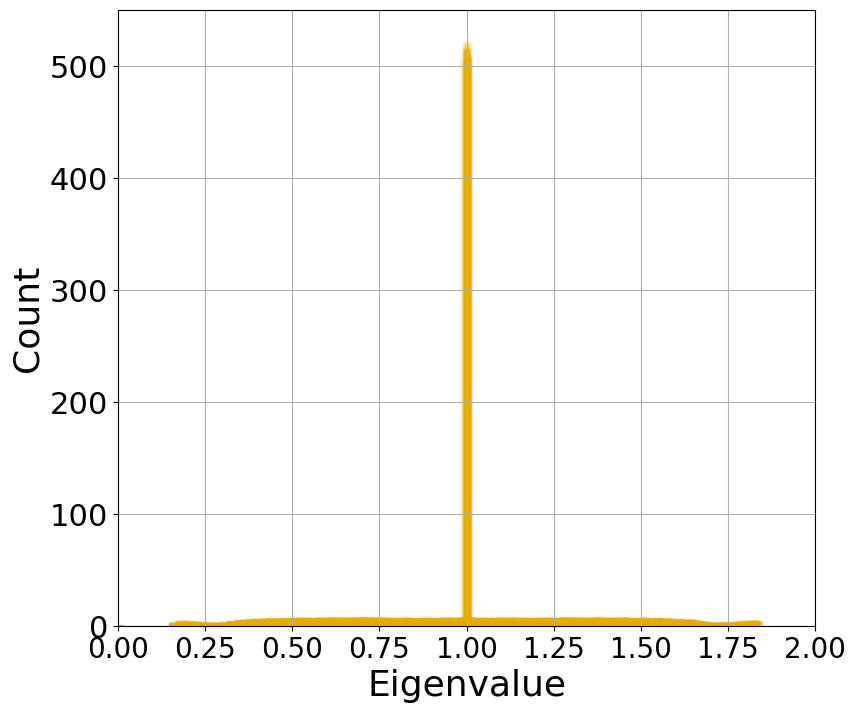

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 500             # Number of nodes in the WS graph
m = 3               # Number of edges each new node connects to
num_leafs = 25      # Number of leaf nodes to add to the highest degree nodes
num_top_nodes = 20  # Number of highest degree nodes to add leaf nodes to
num_plots = 100     # Number of graph instances to generate

# Function to create the BA graph and add leaf nodes to the top "num_top_nodes" highest degree nodes
def create_graph_with_leaf_nodes(n, m, num_leafs, num_top_nodes, seed):
    G = nx.barabasi_albert_graph(n, m, seed = seed)
    sorted_nodes = sorted(G.nodes(), key=lambda node: G.degree(node), reverse=True)
    top_nodes = sorted_nodes[:num_top_nodes]
    for node in top_nodes:
        for _ in range(num_leafs):
            leaf_node = max(G.nodes()) + 1 
            G.add_node(leaf_node) 
            G.add_edge(node, leaf_node)
    return G


plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = create_graph_with_leaf_nodes(n, m, num_leafs, num_top_nodes, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=0.05, color='#e6ab02')

plt.xlabel('Eigenvalue', fontsize = 26)
plt.ylabel('Count', fontsize = 26)
plt.xticks(fontsize=20)
plt.yticks(fontsize=22)
plt.xlim(0, 2)
plt.ylim(0, 550)
plt.grid(True)

file_name = f'Random_graph_plots/BA_leafs_{num_leafs}_m_{m}_n_{n}_top_{num_top_nodes}.pdf'
plt.savefig(file_name)
plt.show()

# WS with leafs

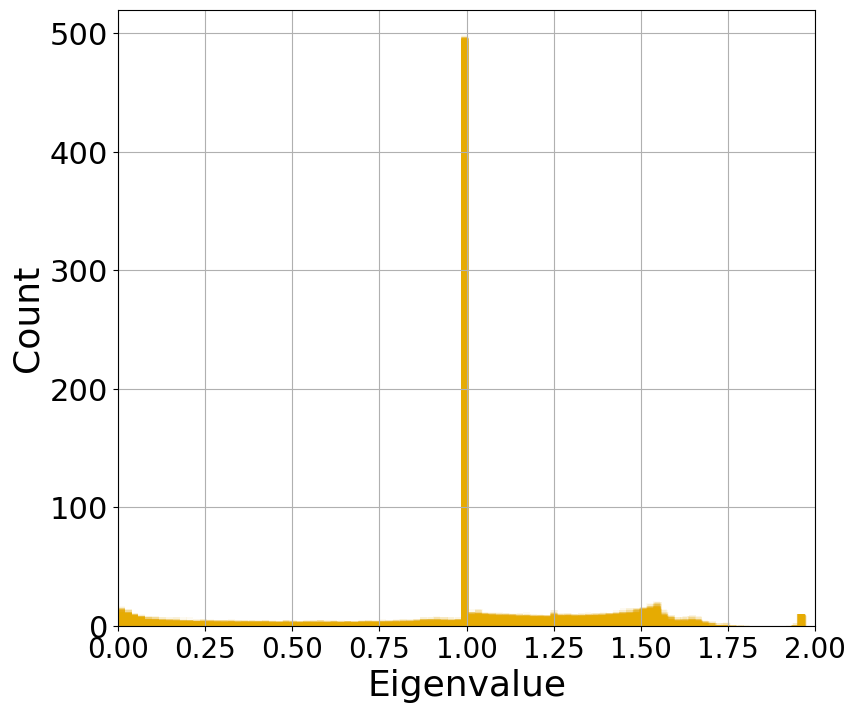

In [87]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 500             # Number of nodes in the WS graph
k = 4               # Each node is connected to k nearest neighbors
p = 0.05            # Probability of rewiring
num_leafs = 50      # Number of leaf nodes to add to the highest degree nodes
num_top_nodes = 10  # Number of highest degree nodes to add leaf nodes to
num_plots = 100     # Number of graph instances to generate

# Function to create the WS graph and add leaf nodes to the top "num_top_nodes" highest degree nodes
def create_graph_with_leaf_nodes(n, k, p, num_leafs, num_top_nodes, seed):
    G = nx.watts_strogatz_graph(n, k, p, seed = seed)
    sorted_nodes = sorted(G.nodes(), key=lambda node: G.degree(node), reverse=True)
    top_nodes = sorted_nodes[:num_top_nodes]
    for node in top_nodes:
        for _ in range(num_leafs):
            leaf_node = max(G.nodes()) + 1 
            G.add_node(leaf_node) 
            G.add_edge(node, leaf_node)
    return G


plt.figure(figsize=(9, 8))

for i in range(num_plots):
    G = create_graph_with_leaf_nodes(n, k, p, num_leafs, num_top_nodes, seed = i)
    L = nx.normalized_laplacian_matrix(G).toarray().astype(np.float64)
    eigenvalues = np.linalg.eigvalsh(L)
    plt.hist(eigenvalues, bins=100, density=False, alpha=0.05, color='#e6ab02')

plt.xlabel('Eigenvalue', fontsize = 26)
plt.ylabel('Count', fontsize = 26)
plt.xticks(fontsize=20)
plt.yticks(fontsize=22)
plt.xlim(0, 2)
plt.ylim(0, 520)
plt.grid(True)

file_name = f'Random_graph_plots/WS_leafs_{num_leafs}_k_{k}_p_{p}_n_{n}_top_{num_top_nodes}.pdf'
plt.savefig(file_name)
plt.show()